# **Código en python para el análisis de EEG**
Ejemplo de código para análisis de señal EEG: Filtros y espectro de potencia.
## **Ploteo de resultados para la Prueba 4. EEG artefacto cada 2 segundos**

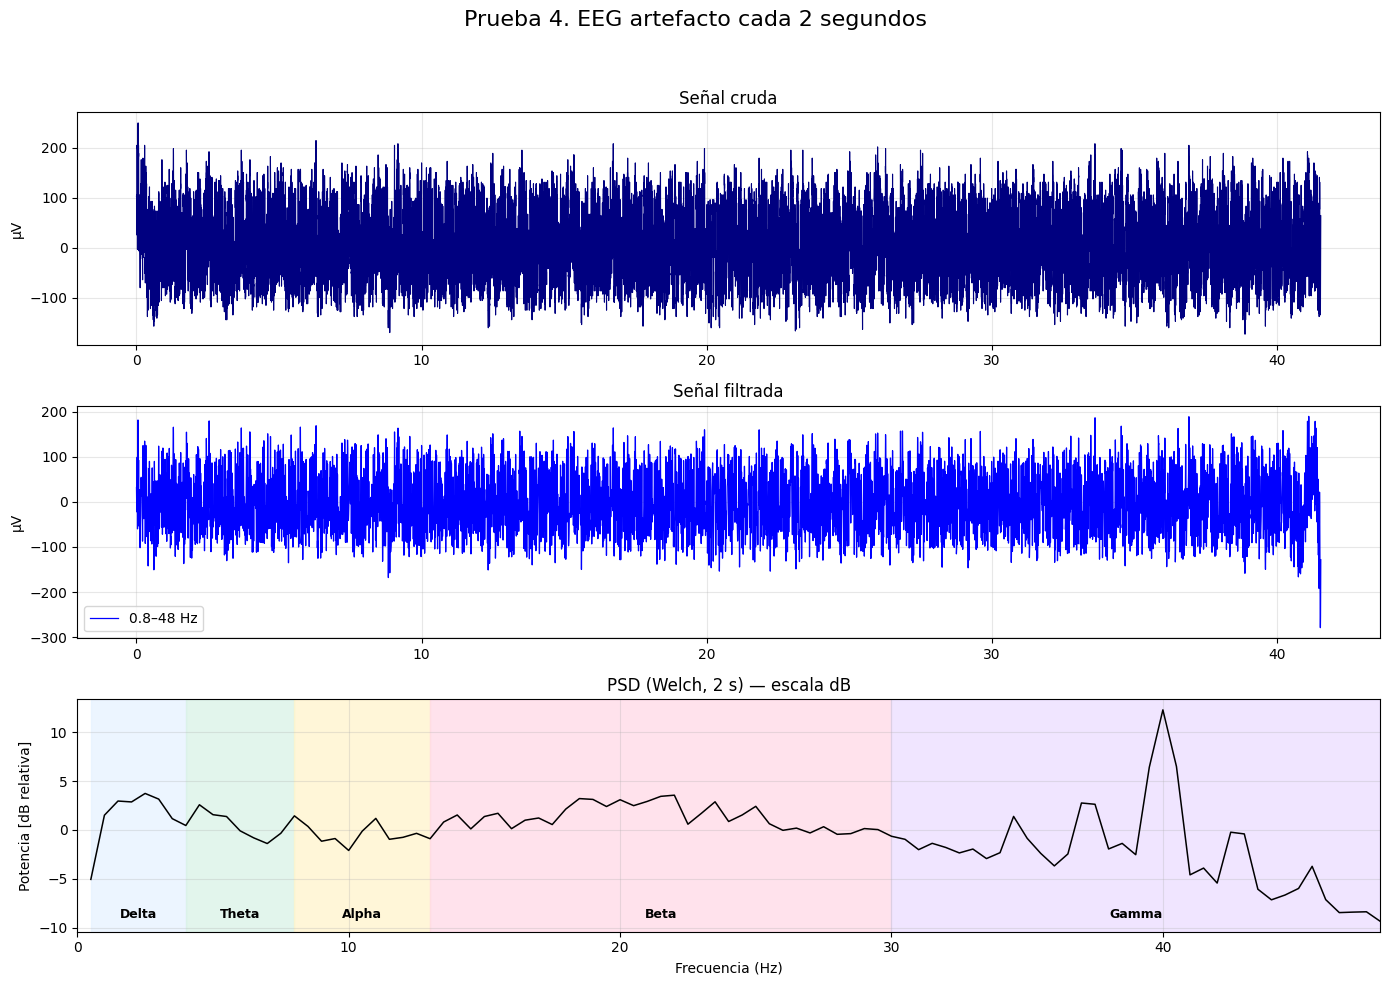

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

# ---------------- Parámetros ----------------
Fs = 1000
bands = {"Delta":(0.5,4), "Theta":(4,8), "Alpha":(8,13), "Beta":(13,30), "Gamma":(30,48)}
fills = {"Delta":"#E6F2FF","Theta":"#D9F2E6","Alpha":"#FFF4CC","Beta":"#FFD9E6","Gamma":"#EBDDFF"}
DB_MODE = "relative"  # "relative" (recomendado) o "absolute"

# ------------- 1) Carga y conversión (ADC→µV) -------------
adc = np.loadtxt("Señales bitalino/eeg_4.2.txt", usecols=[-1])  # A4 (0–1023)
eeg_uV = (adc - 512.0) * 3.2
eeg_uV -= np.median(eeg_uV)
t = np.arange(len(eeg_uV)) / Fs

# ------------- 2) Band-pass 0.8–48 Hz -------------
def bandpass(x, fs, f1=0.8, f2=48, order=4):
    from scipy.signal import butter, filtfilt
    b, a = butter(order, [f1/(fs/2), f2/(fs/2)], btype="band")
    return filtfilt(b, a, x)
x_filt_uV = bandpass(eeg_uV, Fs, 0.8, 48, order=4)

# ------------- 3) PSD estilo EEG -------------
# a) Señal a voltios y Welch con densidad (V²/Hz)
x_filt_V = x_filt_uV * 1e-6
nper = int(2*Fs); nover = nper//2
f, Pxx_V2Hz = welch(x_filt_V, fs=Fs, nperseg=nper, noverlap=nover,
                    window="hann", detrend="constant", scaling="density")
m = (f>=0.5) & (f<=48); f, Pxx_V2Hz = f[m], Pxx_V2Hz[m]
eps = np.finfo(float).eps

# b) Escala dB adecuada
if DB_MODE == "absolute":
    Pxx_dB = 10*np.log10(Pxx_V2Hz + eps)         # dB re V²/Hz
    ylab = "Potencia [dB re V²/Hz]"
else:
    ref = np.median(Pxx_V2Hz)                    # referencia interna para comparar
    Pxx_dB = 10*np.log10((Pxx_V2Hz+eps)/(ref+eps))  # dB relativos (mediana=0 dB)
    ylab = "Potencia [dB relativa]"

# ------------- 4) Gráficas -------------
plt.figure(figsize=(14,10))
plt.suptitle("Prueba 4. EEG artefacto cada 2 segundos", fontsize=16)

# Cruda (µV)
plt.subplot(3,1,1)
plt.plot(t, eeg_uV, lw=0.8, color="navy")
plt.title("Señal cruda"); plt.ylabel("µV"); plt.grid(True, alpha=0.3)

# Filtrada (µV)
plt.subplot(3,1,2)
plt.plot(t, x_filt_uV, lw=0.9, color="blue", label="0.8–48 Hz")
plt.title("Señal filtrada"); plt.ylabel("µV"); plt.grid(True, alpha=0.3); plt.legend()

# PSD (dB)
plt.subplot(3,1,3)
for name,(a,b) in bands.items():
    plt.axvspan(a,b,color=fills[name],alpha=0.75,zorder=0)
    plt.text((a+b)/2, Pxx_dB.min(), name, ha="center", va="bottom", fontsize=9, weight="bold")
plt.plot(f, Pxx_dB, color="black", lw=1.1)
plt.title("PSD (Welch, 2 s) — escala dB")
plt.xlabel("Frecuencia (Hz)"); plt.ylabel(ylab)
plt.xlim(0,48); plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.95]); plt.show()


## **Comparación potencia α en ojos abiertos vs. cerrados**

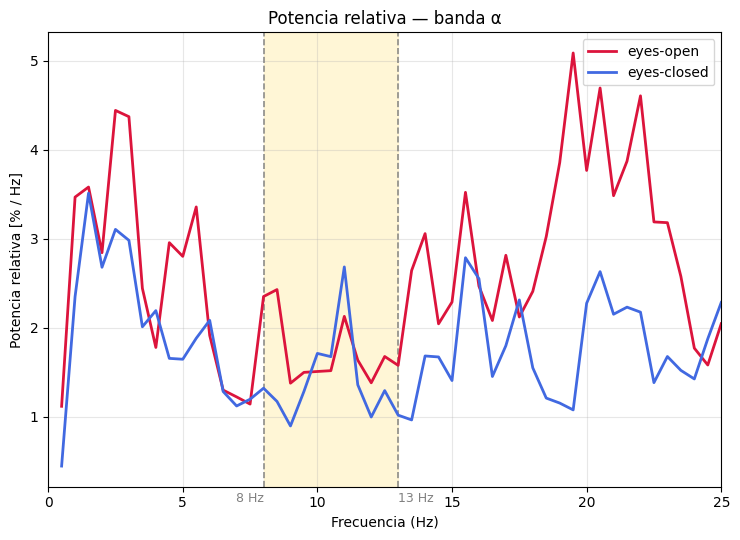

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

# ---------------- Parámetros ----------------
Fs = 1000
ALPHA = (8, 13)
F_MIN, F_MAX = 0.5, 48
T0, T1 = 20.0, 50.0
FILES = {
    "eyes-closed": "Señales bitalino/eeg_1_reposo.txt",
    "eyes-open":   "Señales bitalino/eeg_2.1_reposo_vista.txt",
}
COLORS = {"eyes-closed": "royalblue", "eyes-open": "crimson"}

# ---------------- Utilidades ----------------
def bandpass(x, fs, f1=0.8, f2=48, order=4):
    b, a = butter(order, [f1/(fs/2), f2/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def adc_to_uV(adc):
    x = (adc - 512.0) * 3.2
    return x - np.median(x)

def relative_psd_uV2Hz(x_uV, fs, f_lo=F_MIN, f_hi=F_MAX):
    f, Pxx = welch(x_uV, fs=fs, nperseg=2*fs, noverlap=fs,
                   window="hann", detrend="constant", scaling="density")
    m = (f >= f_lo) & (f <= f_hi)
    f, Pxx = f[m], Pxx[m]
    Ptot = np.trapezoid(Pxx, f)
    Pxx_rel = Pxx / Ptot if Ptot > 0 else Pxx*0.0
    return f, Pxx_rel

# ---------------- Preparar curvas (20–50 s) ----------------
curves = {}
for label, path in FILES.items():
    adc = np.loadtxt(path, usecols=[-1])
    i0, i1 = int(T0*Fs), int(T1*Fs)
    x_uV = adc_to_uV(adc[i0:i1])
    x_filt = bandpass(x_uV, Fs, 0.8, 48)
    f, Pxx_rel = relative_psd_uV2Hz(x_filt, Fs)
    keep = f <= 25
    curves[label] = (f[keep], Pxx_rel[keep])

# ---------------- Gráfica comparativa ----------------
plt.figure(figsize=(7.5, 5.5))

# sombreado α
plt.axvspan(ALPHA[0], ALPHA[1], color="#FFF4CC", alpha=0.8, zorder=0)
# líneas verticales que delimitan α
for v in ALPHA:
    plt.axvline(v, color="gray", linestyle="--", linewidth=1.2, alpha=0.9)
plt.text(ALPHA[0], 0, "8 Hz", ha="right", va="bottom", fontsize=9, color="gray")
plt.text(ALPHA[1], 0, "13 Hz", ha="left", va="bottom", fontsize=9, color="gray")

# curvas (%/Hz)
for label in ["eyes-open", "eyes-closed"]:
    f, y = curves[label]
    plt.plot(f, y*100, lw=2.0, color=COLORS[label], label=label)

plt.title("Potencia relativa — banda α")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia relativa [% / Hz]")
plt.xlim(0, 25)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## **Evaluar incremento de β durante la tarea cognitiva**

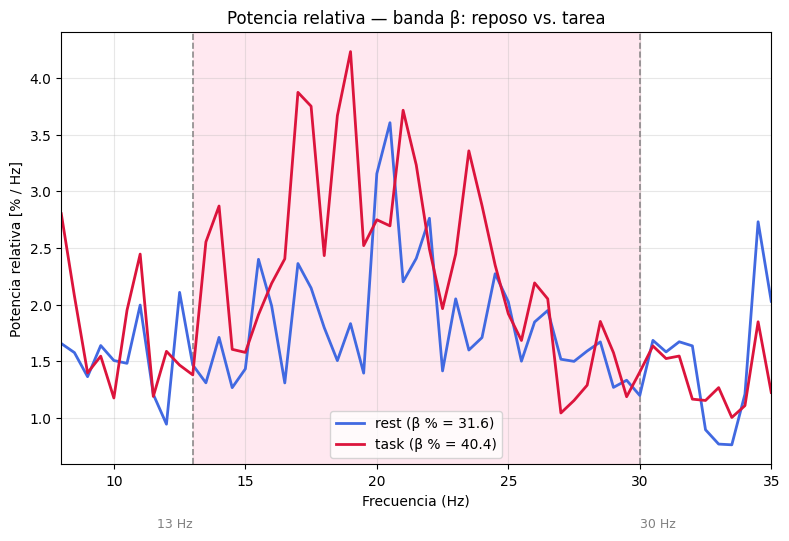

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

# ---------------- Parámetros ----------------
Fs = 1000
BETA = (13, 30)
F_MIN, F_MAX = 0.5, 48
T0, T1 = 10.0, 40.0  # intervalo a analizar (s)

FILES = {
    "rest": "Señales bitalino/eeg_1_reposo.txt",
    "task": "Señales bitalino/eeg_3_resta_0_40s.txt",
}
COLORS = {"rest": "royalblue", "task": "crimson"}

# ---------------- Utilidades ----------------
def bandpass(x, fs, f1=0.8, f2=48, order=4):
    b, a = butter(order, [f1/(fs/2), f2/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def adc_to_uV(adc):
    """ADC (0..1023) → µV; centrar en 0.5·Vref y remover DC residual."""
    x = (adc - 512.0) * 3.2
    return x - np.median(x)

def relative_psd_uV2Hz(x_uV, fs, f_lo=F_MIN, f_hi=F_MAX):
    """Welch (2 s, 50%), PSD en µV²/Hz; normaliza por potencia total 0.5–48 Hz."""
    f, Pxx = welch(x_uV, fs=fs, nperseg=2*fs, noverlap=fs,
                   window="hann", detrend="constant", scaling="density")
    m = (f >= f_lo) & (f <= f_hi)
    f, Pxx = f[m], Pxx[m]
    Ptot = np.trapezoid(Pxx, f)
    Pxx_rel = Pxx / Ptot if Ptot > 0 else Pxx*0.0
    return f, Pxx_rel

# ---------------- Preparar curvas (10–40 s) ----------------
curves = {}
beta_area = {}
for label, path in FILES.items():
    adc = np.loadtxt(path, usecols=[-1])
    i0, i1 = int(T0*Fs), int(T1*Fs)
    x_uV = adc_to_uV(adc[i0:i1])
    x_filt = bandpass(x_uV, Fs, 0.8, 48)
    f, Pxx_rel = relative_psd_uV2Hz(x_filt, Fs)

    # quedarnos con 8–35 Hz para contextualizar β
    keep = (f >= 8) & (f <= 35)
    curves[label] = (f[keep], Pxx_rel[keep])

    # potencia relativa integrada en β (13–30 Hz)
    mbeta = (f >= BETA[0]) & (f <= BETA[1])
    beta_area[label] = np.trapezoid(Pxx_rel[mbeta], f[mbeta]) * 100  # %

# ---------------- Gráfica comparativa (zona β) ----------------
plt.figure(figsize=(8, 5.5))

# sombreado y líneas verticales que delimitan β
plt.axvspan(BETA[0], BETA[1], color="#FFD9E6", alpha=0.6, zorder=0)
for v in BETA:
    plt.axvline(v, color="gray", linestyle="--", linewidth=1.2, alpha=0.9)
plt.text(BETA[0], 0, "13 Hz", ha="right", va="bottom", fontsize=9, color="gray")
plt.text(BETA[1], 0, "30 Hz", ha="left", va="bottom", fontsize=9, color="gray")

# curvas (%/Hz)
for label in ["rest", "task"]:
    f, y = curves[label]
    plt.plot(f, y*100, lw=2.0, color=COLORS[label],
             label=f"{label} (β % = {beta_area[label]:.1f})")

plt.title("Potencia relativa — banda β: reposo vs. tarea")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia relativa [% / Hz]")
plt.xlim(8, 35)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## **Detectar artefactos de parpadeo (> 80 µV) y contabilizar su número.**

Artefactos detectados (masticación) en 8–38 s: 7
Tasa: 14.0 eventos/min


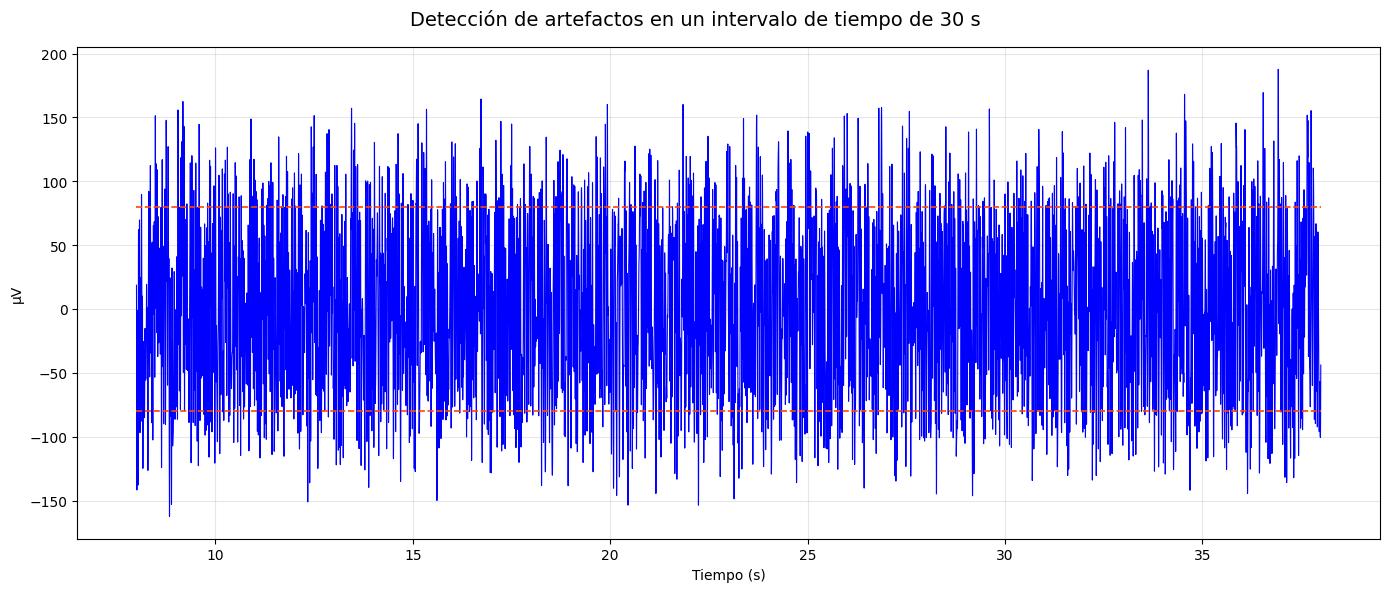

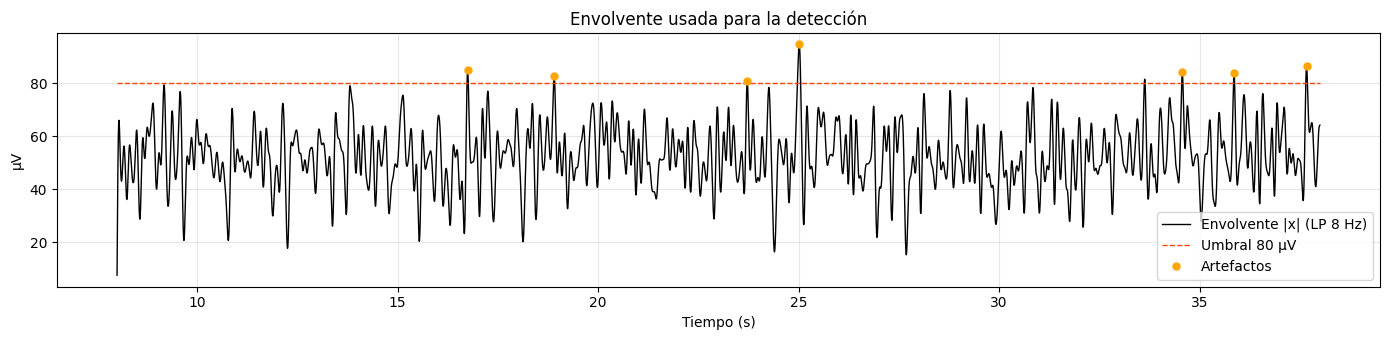

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ---------------- Parámetros ----------------
Fs = 1000
FILE = "Señales bitalino/eeg_4.2.txt"
T0, T1 = 8.0, 38.0
THR_uV = 80.0          # umbral (ajustable)
REFRACTORY_S = 1.0     # distancia mínima entre eventos (s)

# ---------------- Utilidades ----------------
def adc_to_uV(adc):
    x = (adc - 512.0) * 3.2
    return x - np.median(x)

def butter_bandpass(x, fs, f1=0.8, f2=48, order=4):
    b, a = butter(order, [f1/(fs/2), f2/(fs/2)], btype="band")
    return filtfilt(b, a, x)

def envelope_abs(x, fs, lp=8.0, order=4):
    b, a = butter(order, lp/(fs/2), btype="low")
    return filtfilt(b, a, np.abs(x))

def detect_artifacts(x_filt, fs, thr_uV=150.0, refractory_s=1.0):
    env = envelope_abs(x_filt, fs, lp=8.0)
    idx, _ = find_peaks(env, height=thr_uV, distance=int(refractory_s*fs))
    return idx, env

# ---------------- 1) Carga, recorte y filtrado ----------------
adc = np.loadtxt(FILE, usecols=[-1])
i0, i1 = int(T0*Fs), int(T1*Fs)
t = np.arange(i0, i1) / Fs

x_uV = adc_to_uV(adc[i0:i1])
x_filt = butter_bandpass(x_uV, Fs, 0.8, 48)

# ---------------- 2) Detección con envolvente ----------------
peaks_idx, env = detect_artifacts(x_filt, Fs, thr_uV=THR_uV, refractory_s=REFRACTORY_S)
n_events = len(peaks_idx)
print(f"Artefactos detectados (masticación) en {T0:.0f}–{T1:.0f} s: {n_events}")
if n_events:
    print(f"Tasa: {n_events/(T1-T0)*60:.1f} eventos/min")

# ---------------- 3) Gráfica de la señal filtrada (solo umbral) ----------------
plt.figure(figsize=(14, 6))
plt.suptitle(f"Detección de artefactos en un intervalo de tiempo de 30 s", fontsize=14)

plt.plot(t, x_filt, color="blue", lw=0.8)
plt.hlines([+THR_uV, -THR_uV], t[0], t[-1], colors="orangered", linestyles="--", linewidth=1.2)
plt.ylabel("µV"); plt.xlabel("Tiempo (s)"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ---------------- 4) Gráfica de la envolvente con puntos y leyenda ----------------
plt.figure(figsize=(14, 3.5))
plt.plot(t, env, color="black", lw=1.0, label="Envolvente |x| (LP 8 Hz)")
plt.hlines([THR_uV], t[0], t[-1], colors="orangered", linestyles="--", linewidth=1.0, label=f"Umbral {THR_uV:.0f} µV")
if n_events:
    plt.plot(t[peaks_idx], env[peaks_idx], "o", ms=5, color="orange", label="Artefactos")

plt.title("Envolvente usada para la detección")
plt.ylabel("µV"); plt.xlabel("Tiempo (s)")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")   # << aquí cambiamos la posición de la leyenda
plt.tight_layout(); plt.show()